In [ ]:
# Install packages
!pip install swig mediapy
!pip install mujoco==3.1.4
!pip install torch torchrl
!pip install gymnasium[box2d,mujoco]==0.28.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3

# Imports and Functions

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
from IPython.display import HTML
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import mediapy as media


In [ ]:
def render_episode(policy, env):
	frames = []
	score = 0
	state = env.reset()[0]
	terminated = truncated = False
	while not terminated and not truncated:
		frame = env.render()
		frames.append(frame)
		action = policy(state)
		state, reward, terminated, truncated, _ = env.step(action)
		score += reward
	env.close()
	print(f"Finished episode. Cummulative Return: {score}")
	media.show_video(frames, fps=100, loop=True)

# Perception in Robotics
Perception in robotics refers to the ability of robots to sense and interpret their environment using various sensors such as cameras, LiDAR, radar, and touch sensors. This capability is crucial for enabling robots to navigate, interact with, and make decisions about their surroundings. Perception allows robots to perform tasks such as object recognition, localization, and mapping, which are essential for applications ranging from industrial automation to autonomous driving. In the context of learning-based control of robotic systems, perception plays a pivotal role by providing the necessary sensory data that informs decision-making processes. Learning from raw input data, such as images, involves directly processing high-dimensional sensory inputs to extract meaningful features, which can be computationally intensive and data-hungry. In contrast, learning from dense state representations involves using pre-processed, compact representations of the environment, which can simplify the learning process and improve efficiency by focusing on the most relevant aspects of the sensory data.

## Noisy Sensor Data
Noisy sensors are a common challenge in robotics. Sensors are used to gather information about the environment, such as position, distance, or object detection. However, these sensors are not perfect and can introduce errors or inaccuracies in their measurements. This noise can be caused by various factors, including sensor limitations, environmental conditions, or interference. The presence of noise in sensor data can lead to incorrect or unreliable information, which can significantly impact the performance and reliability of robotic systems. To mitigate the effects of noisy sensors, various techniques are employed, such as sensor fusion, filtering algorithms, or calibration procedures. These methods aim to improve the accuracy and reliability of sensor measurements, enabling robots to make more informed decisions and operate effectively in real-world scenarios.

## Partial Observation
Partial observation is a significant challenge in robotics, where robots often have limited access to complete and accurate information about their environment. Due to the constraints of sensors and the complexity of real-world scenarios, robots may only be able to observe a subset of the relevant data. This partial observation can lead to incomplete or distorted perceptions of the environment, making it difficult for robots to make informed decisions and navigate effectively. To address this issue, robotics researchers and engineers employ various techniques such as sensor fusion, probabilistic modeling, and machine learning algorithms to infer and estimate the missing information. By combining multiple sources of data and leveraging advanced algorithms, robots can enhance their perception capabilities and overcome the limitations of partial observation, enabling them to operate more autonomously and effectively in complex real-world environments.

## Kalman Filter
The Kalman filter is a mathematical algorithm used for estimating the state of a system based on incomplete and noisy measurements. It is widely used in robotics for sensor fusion, where multiple sensors provide different measurements of the same physical quantity.

In the context of robotics, the Kalman filter is used to estimate the state of a robot, such as its position, velocity, or orientation, by combining measurements from various sensors, such as GPS, IMU, or vision sensors. The filter takes into account the uncertainty in the measurements and the dynamics of the system to provide an optimal estimate of the state.

The important parameters of the Kalman filter include:

1. Initial state: This is the initial estimate of the state of the system. It represents the best guess of the state before any measurements are available.

2. Initial covariance: This is the initial estimate of the uncertainty in the state. It represents the confidence in the initial state estimate.

3. Measurement matrix: This matrix relates the measurements to the state variables. It defines how the measurements are related to the state of the system.

4. Measurement noise covariance: This matrix represents the uncertainty in the measurements. It captures the noise and errors in the sensor measurements.

5. Transition matrix: This matrix describes the dynamics of the system. It defines how the state variables evolve over time.

6. Process noise covariance: This matrix represents the uncertainty in the system dynamics. It captures the noise and errors in the system model.

The Kalman filter algorithm consists of two main steps: prediction and update. In the prediction step, the filter uses the transition matrix and process noise covariance to predict the next state of the system. In the update step, the filter combines the predicted state with the measurements using the measurement matrix and measurement noise covariance to obtain an updated estimate of the state.

By iteratively performing the prediction and update steps, the Kalman filter continuously refines its estimate of the state, taking into account the measurements and the dynamics of the system. This allows the filter to provide an accurate and robust estimate of the state, even in the presence of noise and uncertainties.


In [ ]:
# A simple Kalman filter implementation
class KalmanFilter:
    def __init__(self, initial_state, initial_covariance, measurement_matrix, measurement_noise_covariance, transition_matrix, process_noise_covariance):
        self.state = initial_state
        self.covariance = initial_covariance
        self.measurement_matrix = measurement_matrix
        self.measurement_noise_covariance = measurement_noise_covariance
        self.transition_matrix = transition_matrix
        self.process_noise_covariance = process_noise_covariance

    def predict(self):
        self.state = self.transition_matrix@self.state
        self.covariance = self.transition_matrix@self.covariance@self.transition_matrix.T + self.process_noise_covariance

    def update(self, measurement):
        innovation = measurement - self.measurement_matrix@self.state
        innovation_covariance = self.measurement_matrix@self.covariance@self.measurement_matrix.T + self.measurement_noise_covariance
        kalman_gain = self.covariance@self.measurement_matrix.T@np.linalg.inv(innovation_covariance)

        self.state = self.state + kalman_gain@innovation
        self.covariance = (np.identity(len(self.state)) - kalman_gain @ self.measurement_matrix) @ self.covariance @ \
            (np.identity(len(self.state)) - kalman_gain @ self.measurement_matrix).T + kalman_gain @ self.measurement_noise_covariance @ kalman_gain.T

In [ ]:
# We here visualize the uncertainty propagation of a one-dimensional particle.
# In addition to dealing with the noise of the position measurements, we estimate the velocity
# Define the Kalman filter parameters
initial_state = np.array([0, 0])
initial_covariance = np.array([[2, 0], [0, 2]])
measurement_matrix = np.array([[1, 0]])
measurement_noise_covariance = np.array([[0.5]])
transition_matrix = np.array([[1, 1], [0, 1]])
process_noise_covariance = np.array([[0.001, 0], [0, 0.01]])
kalman_filter = KalmanFilter(initial_state, initial_covariance, measurement_matrix, measurement_noise_covariance, transition_matrix, process_noise_covariance)

# Generate noisy measurements
measurements = (np.linspace(1, 20, 20) + np.random.normal(loc=0, scale=0.5**2, size=20)).reshape(-1, 1)
estimations = np.zeros((len(measurements)+1, 2))
estimations[0] = kalman_filter.state
covariances = np.zeros((len(measurements)+1, 2, 2))
covariances[0] = kalman_filter.covariance

# Perform uncertainty propagation
for i, measurement in enumerate(measurements):
    kalman_filter.predict()
    kalman_filter.update(measurement)
    estimations[i+1] = kalman_filter.state
    covariances[i+1] = kalman_filter.covariance

def ellipse(cov_matrix):
    pearson = cov_matrix[0, 1]/np.sqrt(cov_matrix[0, 0] * cov_matrix[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    angle = 0.5 * np.arctan2(2 * cov_matrix[0, 1], (cov_matrix[0, 0] - cov_matrix[1, 1]))
    width = ell_radius_x * 2 * np.sqrt(cov_matrix[0, 0])
    height = ell_radius_y * 2 * np.sqrt(cov_matrix[1, 1])
    angle = np.degrees(angle)
    return width, height, angle

# Render the uncertainty propagation as a video
fig, ax = plt.subplots()
xdata, ydata = [], []
traj, = ax.plot([], [], 'b')
s, = ax.plot([], [],'o', c='b')
c = Ellipse((0, 0), 1, 1, fill=True, color='b', alpha=0.2, lw=.5)
ax.plot([], [], 'r', label='noisy measurements')
ax.plot([], [], 'b', label='state estimate')
ax.legend()
plt.close()

def init():
    ax.set_xlim(-1, 21)
    ax.set_ylim(-1, 2)
    ax.set_xlabel('position')
    ax.set_ylabel('velocity')
    ax.add_patch(c)
    return traj, s, c
def update(i):
    xdata.append(estimations[i,0])
    ydata.append(estimations[i,1])
    traj.set_data(xdata, ydata)
    s.set_data([estimations[i,0]], [estimations[i,1]])
    c.center = (estimations[i,0], estimations[i,1])
    cov = covariances[i]
    c.width, c.height, c.angle = ellipse(cov)
    if i>0:
        ax.axvline(measurements[i-1], c = 'r', linewidth=0.7)
    return traj, s, c
ani = FuncAnimation(fig, update, len(estimations),
                    init_func=init, blit=True, interval=1000)
HTML(ani.to_html5_video())

In [ ]:
# Two dimensional measurements
# Initialize a Kalman Filter that takes in noisy measurements of a 2D position and estimates the position and velocity
initial_state = np.array([0, 0, 0, 0])  # (e.g., [x, y, vx, vy] in 2D).
initial_covariance = np.identity(4)  # (unit covariance for x, y, vx, vy).  Decrease to initial_covariance = np.identity(4) * 0.01 (low uncertainty).
measurement_matrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])  # Maps the state to the measurement space (e.g., measures only position, not velocity). measures x, y.
measurement_noise_covariance = np.identity(2) * 0.1**2
transition_matrix = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]])  # Defines the system’s dynamics (how the state evolves over time). constant velocity model.
process_noise_covariance = np.diag([1e-5,1e-5,1e-4,1e-4])  # small noise for position, larger for velocity.

kalman_filter = KalmanFilter(initial_state, initial_covariance, measurement_matrix, measurement_noise_covariance, transition_matrix, process_noise_covariance)

# Generate ground truth trajectory
ground_truth = np.zeros((200, 2))
for i in range(200):
    t = i / 200 * 2 * np.pi
    x = np.sin(t) + np.sin(2 * t)
    y = np.cos(t) - np.cos(2 * t)
    ground_truth[i] = [x, y]

# Generate noise measurements
measurements = np.random.normal(0, 0.1, (200, 2)) + ground_truth
estimations = np.zeros((len(measurements), 4))
covariances = np.zeros((len(measurements), 4, 4))

# Run the Kalman filter over the noise measurements
for i, measurement in enumerate(measurements):
    kalman_filter.predict()
    kalman_filter.update(measurement)
    estimations[i] = kalman_filter.state
    covariances[i] = kalman_filter.covariance

# Render the uncertainty propagation as a video
fig, ax = plt.subplots()
xest, yest = [], []
xmeas, ymeas = [], []
traj, = ax.plot([], [], 'b')
s, = ax.plot([], [],'o', c='b', label='state estimate')
meas, = ax.plot([],[], 'o', c='r', label='measurements')
ax.legend()
plt.close()

def init():
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_xlabel('position')
    ax.set_ylabel('velocity')
    return traj, meas, s
def update(i):
    xest.append(estimations[i,0])
    yest.append(estimations[i,1])
    xmeas.append(measurements[i,0])
    ymeas.append(measurements[i,1])
    traj.set_data(xest, yest)
    meas.set_data(xmeas,ymeas)
    s.set_data([estimations[i,0]], [estimations[i,1]])
    return traj, meas, s
ani = FuncAnimation(fig, update, len(estimations),
                    init_func=init, blit=True, interval=100)
HTML(ani.to_html5_video())

### Tasks
1. Play around with the parameters of the Kalman filter to understand what they are doing.
2. The Kalman filter features a forward model that is implemented via the transition matrix. What do we assume here?
3. We can imagine the measurements we observe to be noisy GPS data and we use our filter to remove the noise. How can the Kalman filter help us if we stop receiving measurements alltogether?

**Task 2:** The Kalman filter features a forward model that is implemented via the transition matrix. What do we assume here?

**Ans:**  We assume that the system's time evolution and observations are linear, that the noise follows a zero-mean Gaussian distribution, and that the model structure is known.

**Task3**: We can imagine the measurements we observe to be noisy GPS data and we use our filter to remove the noise. How can the Kalman filter help us if we stop receiving measurements alltogether?



**Ans:** Even without measurements, the Kalman filter can predict future states using the model. It continues the prediction step to estimate the state, which is useful for short periods of missing data, such as GPS signal loss.

# Learning to remove noise
We have seen that we can use a Kalman filter (there exist more advanced filters, such as particle filters, extended Kalman filters, or unscented Kalman filters) to deal with noisy measurements, when we have a good model of our world. However, it might also be a good idea to learn how to remove noise from observations; especially, if we do not have a good model of the dynamics of our world or of the noise we are dealing with.

## Denoising Auto-Encoders
Denoising autoencoders are a type of neural network architecture used for unsupervised learning tasks, particularly in the field of image and signal processing. The main objective of denoising autoencoders is to remove noise or unwanted variations from input data, reconstructing a clean version of the original input. This is achieved by training the autoencoder to encode the noisy input into a lower-dimensional representation and then decode it back to the original input, minimizing the reconstruction error. By learning to denoise the data, denoising autoencoders can effectively capture the underlying structure and patterns in the data, making them useful for tasks such as image denoising, anomaly detection, and feature extraction.

In [ ]:
# The denoising Autoencoder model
class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),#1x28x28 -> 16x14x14
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),#16x14x14 -> 8x7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8 * 7 * 7, 64),#8x7x7 -> 64
            nn.ReLU(),
            nn.Linear(64, latent_dim)#64 -> latent_dim
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),#latent_dim -> 64
            nn.ReLU(),
            nn.Linear(64, 8 * 7 * 7),#64 -> 8x7x7
            nn.ReLU(),
            nn.Unflatten(1, (8, 7, 7)),
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),#8x7x7 -> 16x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),#16x14x14 -> 1x28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
# Load the MNIST dataset
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.82MB/s]


In [ ]:
## Main
# Create the denoising autoencoder model
model = DenoisingAutoencoder().to(device)

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    train_loss = 0.0
    # Training
    model.train()
    for images, _ in train_loader:
        images = images.to(device)
        # Add random noise to the input images
        noise = torch.randn_like(images)
        noisy_images = images + 0.2 * noise

        # Forward pass
        outputs = model(noisy_images)

        # Compute the loss
        loss = criterion(outputs, images)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss / len(train_dataset):.4f}")

Epoch 1/50, Training Loss: 0.0750
Epoch 2/50, Training Loss: 0.0584
Epoch 3/50, Training Loss: 0.0538
Epoch 4/50, Training Loss: 0.0515
Epoch 5/50, Training Loss: 0.0500
Epoch 6/50, Training Loss: 0.0491
Epoch 7/50, Training Loss: 0.0483
Epoch 8/50, Training Loss: 0.0476
Epoch 9/50, Training Loss: 0.0471
Epoch 10/50, Training Loss: 0.0468
Epoch 11/50, Training Loss: 0.0464
Epoch 12/50, Training Loss: 0.0461
Epoch 13/50, Training Loss: 0.0458
Epoch 14/50, Training Loss: 0.0455
Epoch 15/50, Training Loss: 0.0452
Epoch 16/50, Training Loss: 0.0449
Epoch 17/50, Training Loss: 0.0447
Epoch 18/50, Training Loss: 0.0445
Epoch 19/50, Training Loss: 0.0443
Epoch 20/50, Training Loss: 0.0442
Epoch 21/50, Training Loss: 0.0441
Epoch 22/50, Training Loss: 0.0439
Epoch 23/50, Training Loss: 0.0438
Epoch 24/50, Training Loss: 0.0437
Epoch 25/50, Training Loss: 0.0436
Epoch 26/50, Training Loss: 0.0435
Epoch 27/50, Training Loss: 0.0435
Epoch 28/50, Training Loss: 0.0434
Epoch 29/50, Training Loss: 0

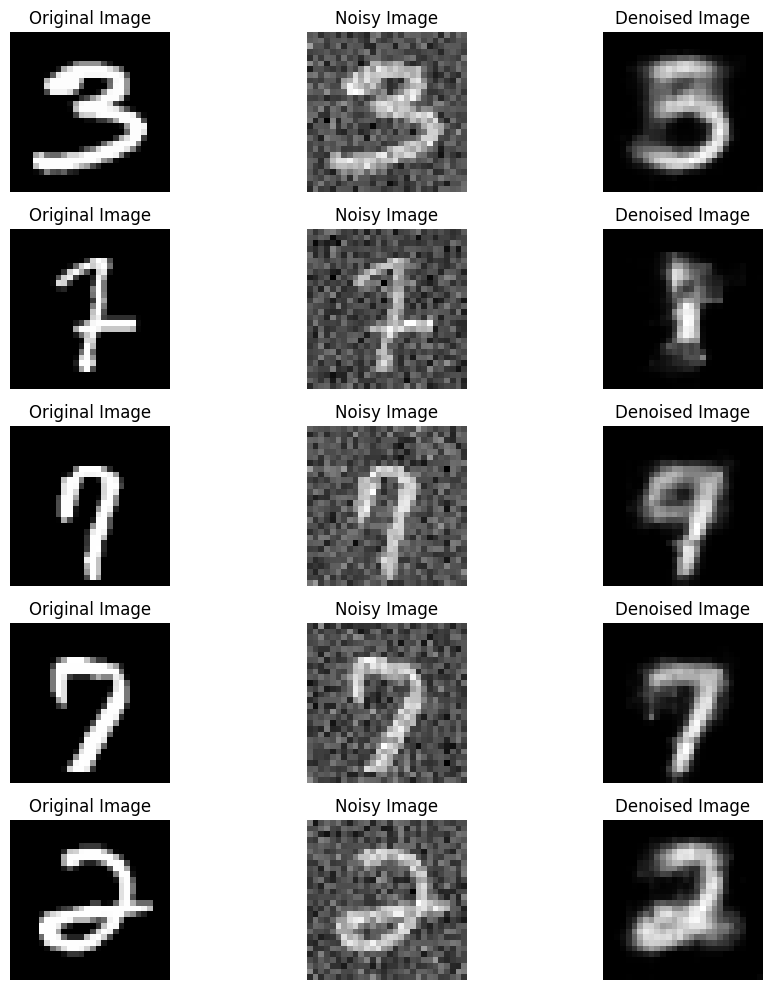

In [ ]:
# Set the number of images to denoise and display
num_images = 5

# Denoise and display the images
fig, axes = plt.subplots(num_images, 3, figsize=(10, 10))

for i in range(num_images):
    # Get the original image
    original_image = train_dataset[np.random.randint(0,len(train_dataset))][0].squeeze().numpy()

    # Add noise to the image
    noise = torch.randn_like(torch.tensor(original_image))
    noisy_image = original_image + 0.2 * noise.squeeze().numpy()

    # Denoise the image using the trained autoencoder
    denoised_image = model(torch.Tensor(noisy_image).to(device).unsqueeze(0).unsqueeze(0)).squeeze().cpu().detach().numpy()

    # Plot the original and denoised images side by side
    axes[i, 0].imshow(original_image, cmap='gray')
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(noisy_image, cmap='gray')
    axes[i, 1].set_title('Noisy Image')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(denoised_image, cmap='gray')
    axes[i, 2].set_title('Denoised Image')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## Latent Spaces
We have seen the ability of the denoising autoenoder to remove noise from noisy images. This is very useful if we have corrupted images. In particular, this not only works with Gaussian noise, but also when we have a part of the image occluded.

Another nice property of (all) autoencoders is their ability to encode a high dimensional input space (e.g., an image) into a lower dimensional latent space. By being forced to compress all information into the bottleneck in the neural network

Latent spaces capture the underlying structure and patterns in the data by representing it in a compressed form. In the context of reinforcement learning, latent spaces offer several benefits. By encoding the high dimensional input space into a lower dimensional latent space, the complexity of the environment is reduced, making it easier for the agent to learn and generalize. Latent spaces also enable the discovery of meaningful representations and features, which can aid in the extraction of relevant information for decision-making. Additionally, the compact representation provided by latent spaces can improve the efficiency of reinforcement learning algorithms by reducing the computational and memory requirements. Overall, latent spaces play a crucial role in reinforcement learning by facilitating efficient representation learning and enhancing the agent's ability to understand and interact with the environment.

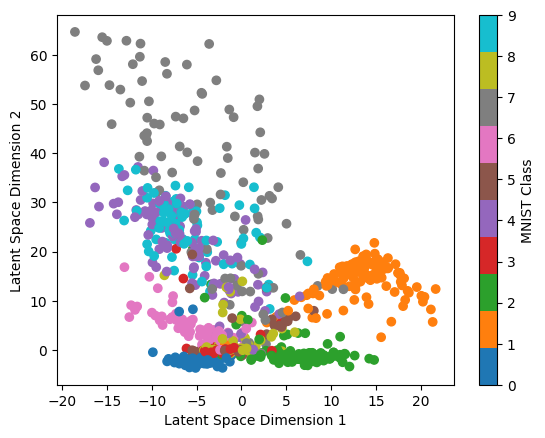

In [ ]:
# Get the latent vectors for the first 1000 images in the test set
images = torch.stack([test_dataset[i][0] for i in range(1000)], dim=0)
labels = test_dataset.targets[:1000]
latent_vectors = model.encoder(images.to(torch.float32).to(device)).cpu().detach().numpy()

# Plot the latent spaces with color indicating the classes
plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels, cmap='tab10')
plt.colorbar(label='MNIST Class')

# Add labels and title
plt.xlabel('Latent Space Dimension 1')
plt.ylabel('Latent Space Dimension 2')

# Show the plot
plt.show()

### Tasks
1. Analyse the latent space. Which classes seem to be easy to to distinguish, which ones are close together in latent space?
2. Autoencoders are so-called generative models, because we can create new examples by choosing a point in latent space and using the decoder to generate an image from it. Write code to generate new images. You can play around with the vector in latent space. What happens when we choose a vector close to the origin/in a region where there is just one class/in an uninhabited region of the latent space (where none of the latent space vectors reside in our visualization)?
3. We here use 2-dimensional latent space that is great for visualizing it but not that great for performance. Recode the NN to find a good tradeoff between dimensionality of your latent space and quality of reconstruction.

**Task: 1.** Analyse the latent space. Which classes seem to be easy to to distinguish, which ones are close together in latent space?


**Ans:**
- **Easily separable classes:** 0 and 1 stand out clearly due to their unique shapes (circle and vertical line).

- **Classes that cluster closely:** for example, 4 & 9 and 3 & 8 tend to overlap in latent space due to similar structure or strokes.



- **Reason:** In a 2D latent space, the model compresses similar features together, so digits with visually similar patterns tend to lie close.

**Task: 2.** What happens when we choose a vector close to the origin/in a region where there is just one class/in an uninhabited region of the latent space (where none of the latent space vectors reside in our visualization)?


**Ans:**
- **Near origin (0,0):** Generates blurry, average-like digits—not clearly any specific class.

- **Inside a dense class region:** Generates clear and sharp samples of that class (e.g., all look like “1”).

- **In an uninhabited area**: Produces noisy or distorted images—sometimes unrecognizable or blank.

**Task: 3.** We here use 2-dimensional latent space that is great for visualizing it but not that great for performance. Recode the NN to find a good tradeoff between dimensionality of your latent space and quality of reconstruction.


**Ans:**
Increasing the dimensionality of the latent space gives the model more capacity to capture complex patterns and reduce reconstruction error. However, it also increases the risk of overfitting, makes the model less interpretable and visualizable.